# Importación del Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fitter import Fitter
from scipy import stats
import kagglehub
from kagglehub import KaggleDatasetAdapter


F:\Simulación\dataset-tp\.simulacionworkspace\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importo dataset

In [36]:
file_path = "./dataset"

kagglehub.dataset_download( "peterfriedrich1/cicdarknet2020-internet-traffic", output_dir=file_path,force_download=True)


100%|██████████| 16.0M/16.0M [00:01<00:00, 8.50MB/s]

Extracting files...


'./dataset'

Observamos los datos

In [3]:
datasetRaw = pd.read_csv("./dataset/Darknet.CSV", on_bad_lines='skip')
datasetRaw

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,10.152.152.11-216.58.220.99-57158-443-6,10.152.152.11,57158,216.58.220.99,443,6,24/07/2015 04:09:48 PM,229,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
1,10.152.152.11-216.58.220.99-57159-443-6,10.152.152.11,57159,216.58.220.99,443,6,24/07/2015 04:09:48 PM,407,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
2,10.152.152.11-216.58.220.99-57160-443-6,10.152.152.11,57160,216.58.220.99,443,6,24/07/2015 04:09:48 PM,431,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
3,10.152.152.11-74.125.136.120-49134-443-6,10.152.152.11,49134,74.125.136.120,443,6,24/07/2015 04:09:48 PM,359,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
4,10.152.152.11-173.194.65.127-34697-19305-6,10.152.152.11,34697,173.194.65.127,19305,6,24/07/2015 04:09:45 PM,10778451,591,400,...,0,0,0,0,1.437765e+15,3.117718e+06,1.437765e+15,1.437765e+15,Non-Tor,AUDIO-STREAMING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141525,10.8.8.246-224.0.0.252-55219-5355-17,10.8.8.246,55219,224.0.0.252,5355,17,22/05/2015 01:55:03 PM,411806,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,VPN,VOIP
141526,10.8.8.246-224.0.0.252-64207-5355-17,10.8.8.246,64207,224.0.0.252,5355,17,22/05/2015 02:09:05 PM,411574,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,VPN,VOIP
141527,10.8.8.246-224.0.0.252-61115-5355-17,10.8.8.246,61115,224.0.0.252,5355,17,22/05/2015 02:19:31 PM,422299,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,VPN,VOIP
141528,10.8.8.246-224.0.0.252-64790-5355-17,10.8.8.246,64790,224.0.0.252,5355,17,22/05/2015 02:29:55 PM,411855,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,VPN,VOIP


In [5]:
#Vemos los tipos de datos de las columnas
datasetRaw.dtypes

Flow ID      object
Src IP       object
Src Port      int64
Dst IP       object
Dst Port      int64
             ...   
Idle Std    float64
Idle Max    float64
Idle Min    float64
Label        object
Label.1      object
Length: 85, dtype: object

# Clasificación de datos

### Variables Exógenas

**Variables de datos:**
* Intervalo entre paquetes
* Tiempo de recepción

**Variables de control:**
* ??

**Variable de estado:**
* Conexiones establecidas

**Variable de resultado:**
* Tiempo promedio de recepción de datos
* Velocidad promedio de subida
* Velocidad promedio de bajada
* Paquetes promedios enviados por conexión


## Gráficos de distribuciones

### Distribución de puertos

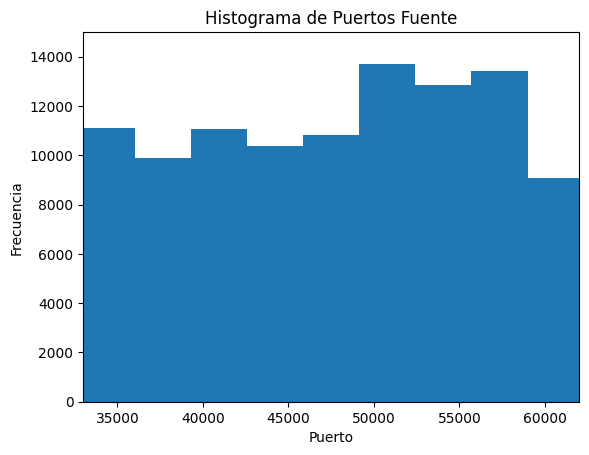

In [6]:
import matplotlib.pyplot as plt

plt.hist(datasetRaw['Src Port'], bins=20)
plt.xlabel('Puerto')
plt.xlim(33000, 62000)
plt.ylabel('Frecuencia')
plt.ylim(0, 15000)
plt.title('Histograma de Puertos Fuente')
plt.show()

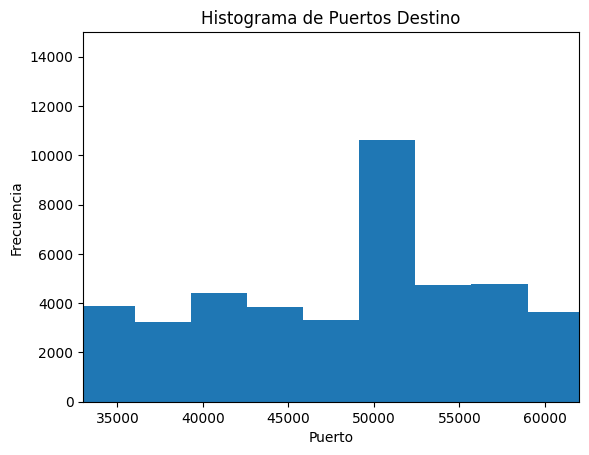

In [7]:
import matplotlib.pyplot as plt

plt.hist(datasetRaw['Dst Port'], bins=20)
plt.xlabel('Puerto')
plt.xlim(33000, 62000)
plt.ylabel('Frecuencia')
plt.ylim(0, 15000)
plt.title('Histograma de Puertos Destino')
plt.show()

In [8]:
dataset_rango = datasetRaw[
    (datasetRaw['Dst Port'] >= 33000) & 
    (datasetRaw['Dst Port'] <= 62000)
]
puerto_mas_frecuente = dataset_rango['Dst Port'].mode()[0]
#El puesto de atención de nuestros eventos será el puerto destino dentro del rango presentado con más conexiones
puerto_mas_frecuente

np.int64(51413)

### Distribución de Protocolos

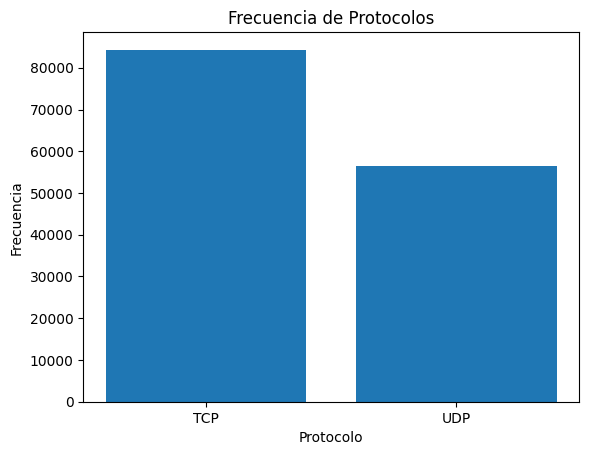

In [9]:
import matplotlib.pyplot as plt

protocol_map = {
    1: 'ICMP',
    6: 'TCP',
    17: 'UDP'
}

datasetRaw['Protocol_label'] = datasetRaw['Protocol'].map(protocol_map)

counts = datasetRaw['Protocol_label'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('Protocolo')
plt.ylabel('Frecuencia')
plt.title('Frecuencia de Protocolos')
plt.show()


# Presentación del caso de uso de la simulación EaE

## QoS de los servidores sobre el puerto 51413 (Quality of Service)

En los servidores on-premise de una empresa tecnológica, los usuarios se conectan mediante el puerto 51413 para acceder a los servicios y aplicaciones.

La empresa se encuentra en expansión y necesita saber si requiere invertir en proyectos para distribuir la carga sobre este puerto particular. Para ello haremos una simulación planteando escenarios con distintas cantidades de servidores y conexiones simultáneas que puedan abarcar con las siguientes definiciones:

* Evento → llegada de un flujo (Timestamp)
* Servicio → procesamiento del flujo (Flow Duration)
* Cola → Puerto 51413. Se puede entrar de distintas IPs provenientes de un Load Balancer.
* Prioridades:
  + Por protocolo (TCP vs UDP): Priorizaremos el protocolo **UDP** ya que suelen ser los que más rápido despachan sus paquetes.

## Generación del Dataframe

In [10]:
datasetFinal = datasetRaw[
    (datasetRaw['Dst Port']==51413)
    ]

datasetFinal = datasetFinal[['Flow ID','Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol_label','Timestamp','Flow Duration']]
datasetFinal

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol_label,Timestamp,Flow Duration
40509,10.152.152.11-94.111.203.124-33393-51413-6,10.152.152.11,33393,94.111.203.124,51413,TCP,24/02/2016 09:48:19 AM,1275
40525,10.152.152.11-117.217.84.124-40839-51413-6,10.152.152.11,40839,117.217.84.124,51413,TCP,24/02/2016 09:48:31 AM,1670613
40527,10.152.152.11-117.217.84.124-40839-51413-6,10.152.152.11,40839,117.217.84.124,51413,TCP,24/02/2016 09:48:33 AM,182296
40536,10.152.152.11-182.18.177.70-47495-51413-6,10.152.152.11,47495,182.18.177.70,51413,TCP,24/02/2016 09:48:34 AM,552135
40537,10.152.152.11-182.18.177.70-47495-51413-6,10.152.152.11,47495,182.18.177.70,51413,TCP,24/02/2016 09:48:35 AM,87992
...,...,...,...,...,...,...,...,...
102316,131.202.240.87-65.98.72.100-61009-51413-17,131.202.240.87,61009,65.98.72.100,51413,UDP,01/05/2015 11:39:00 AM,54869
123216,10.8.8.130-134.173.128.153-51413-51413-17,10.8.8.130,51413,134.173.128.153,51413,UDP,04/06/2015 09:35:04 AM,279664
123466,110.168.232.198-10.8.8.130-48319-51413-17,110.168.232.198,48319,10.8.8.130,51413,UDP,04/06/2015 09:35:31 AM,5303557
123469,10.8.8.130-91.121.198.25-51413-51413-17,10.8.8.130,51413,91.121.198.25,51413,UDP,04/06/2015 09:34:52 AM,126161


Vamos a ver el rango de tiempo que nos quedó en el dataset para simular...

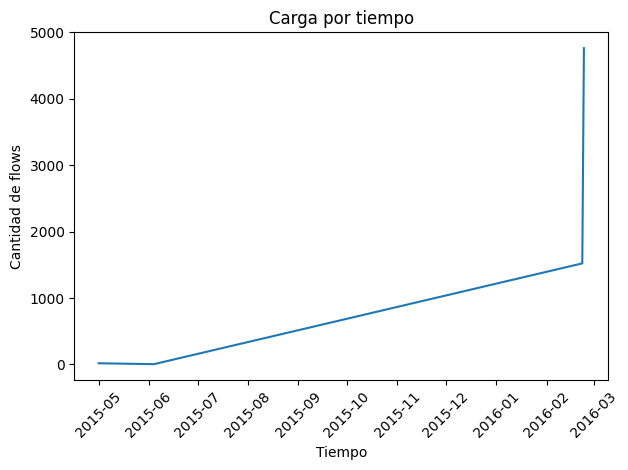

In [11]:
datasetFinal['Timestamp'] = pd.to_datetime(datasetFinal['Timestamp'], dayfirst=True)

carga_por_dia = datasetFinal.groupby(datasetFinal['Timestamp'].dt.date).size()

carga_por_dia.plot()
plt.xlabel('Tiempo')
plt.ylabel('Cantidad de flows')
plt.title('Carga por tiempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Resultado:** 10 meses (casi un año). Los datos son suficientes.

In [12]:
datasetFinal['Timestamp'] = pd.to_datetime(datasetFinal['Timestamp'], dayfirst=True)
datasetFinal = datasetFinal.sort_values('Timestamp')
datasetFinal['IntervaloEntreFlujos'] = datasetFinal['Timestamp'].diff()
datasetFinal['IntervaloEntreFlujos_seg'] = datasetFinal['IntervaloEntreFlujos'].dt.total_seconds()
datasetFinal

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol_label,Timestamp,Flow Duration,IntervaloEntreFlujos,IntervaloEntreFlujos_seg
101549,131.202.240.87-199.195.249.48-61009-51413-17,131.202.240.87,61009,199.195.249.48,51413,UDP,2015-05-01 11:37:47,64007541,NaT,NaN
101591,131.202.240.87-107.191.41.12-61009-51413-17,131.202.240.87,61009,107.191.41.12,51413,UDP,2015-05-01 11:38:51,64049895,0 days 00:01:04,64.0
101590,131.202.240.87-74.207.253.79-61009-51413-17,131.202.240.87,61009,74.207.253.79,51413,UDP,2015-05-01 11:38:51,64106424,0 days 00:00:00,0.0
102316,131.202.240.87-65.98.72.100-61009-51413-17,131.202.240.87,61009,65.98.72.100,51413,UDP,2015-05-01 11:39:00,54869,0 days 00:00:09,9.0
101996,131.202.240.87-79.132.74.152-61009-51413-17,131.202.240.87,61009,79.132.74.152,51413,UDP,2015-05-01 11:39:15,189748,0 days 00:00:15,15.0
...,...,...,...,...,...,...,...,...,...,...
57079,10.152.152.11-103.198.172.77-45213-51413-6,10.152.152.11,45213,103.198.172.77,51413,TCP,2016-02-24 11:33:58,409475,0 days 00:00:00,0.0
60423,10.152.152.11-87.94.140.155-33760-51413-6,10.152.152.11,33760,87.94.140.155,51413,TCP,2016-02-24 11:34:08,4705193,0 days 00:00:10,10.0
81111,10.152.152.11-87.94.140.155-33760-51413-6,10.152.152.11,33760,87.94.140.155,51413,TCP,2016-02-24 11:34:08,4705193,0 days 00:00:00,0.0
81504,10.152.152.11-217.250.238.213-55312-51413-6,10.152.152.11,55312,217.250.238.213,51413,TCP,2016-02-24 11:34:14,1109,0 days 00:00:06,6.0


In [13]:
#Observamos los tipos de dato de las columnas

datasetFinal.dtypes

Flow ID                              object
Src IP                               object
Src Port                              int64
Dst IP                               object
Dst Port                              int64
Protocol_label                       object
Timestamp                    datetime64[ns]
Flow Duration                         int64
IntervaloEntreFlujos        timedelta64[ns]
IntervaloEntreFlujos_seg            float64
dtype: object

Filtramos los outliers y generamos un historigrama para el intervalo entre flujos

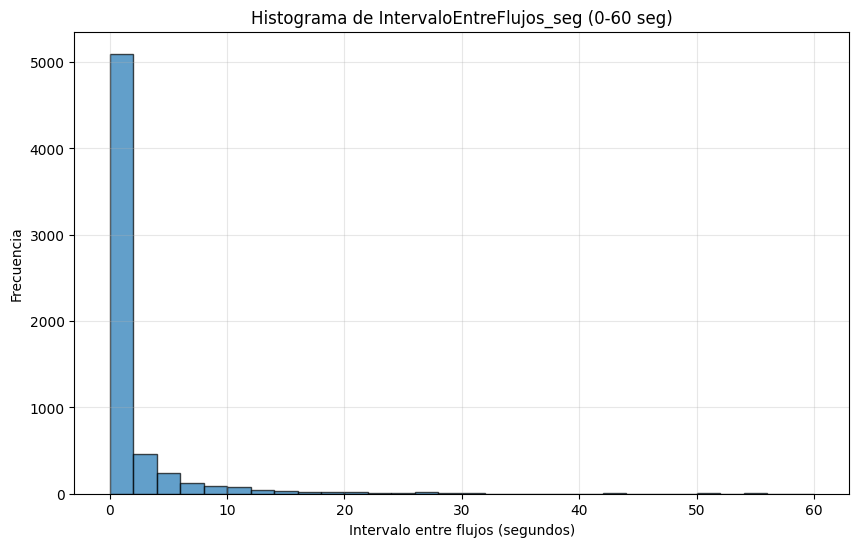

In [14]:
datos_filtrados = datasetFinal[
    (datasetFinal['IntervaloEntreFlujos_seg'] >= 0) & 
    (datasetFinal['IntervaloEntreFlujos_seg'] <= 60)
]['IntervaloEntreFlujos_seg']

plt.figure(figsize=(10, 6))
datos_filtrados.hist(bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Intervalo entre flujos (segundos)')
plt.ylabel('Frecuencia')
plt.title('Histograma de IntervaloEntreFlujos_seg (0-60 seg)')
plt.grid(True, alpha=0.3)
plt.show()

Obtengo la mejor distribución al historigrama de datos de intervalos entre flujos

In [15]:
fdp_IF = Fitter(datos_filtrados)
fdp_IF.fit()
mejor_dist = fdp_IF.get_best()


In [16]:
mejor_dist

{'kappa3': {'a': np.float64(1.9334505996100626),
  'loc': np.float64(-1.4041976152923097e-08),
  'scale': np.float64(0.2975850690131321)}}

Generamos algunos datos para verificar la función obtenida

In [17]:
n_samples = len(datos_filtrados) 
params_kappa3 = mejor_dist['kappa3']
datos_sinteticos = stats.kappa3.rvs(
    a=params_kappa3['a'],
    loc=params_kappa3['loc'],
    scale=params_kappa3['scale']*3, #Multiplico la escala para que se acerque a nuestros datos originales
    size=n_samples,
    random_state=42  # Para reproducibilidad
)
datos_sinteticos = np.clip(datos_sinteticos, 0, 60)
type(datos_sinteticos)

numpy.ndarray

Comparando histogramas

<Axes: >

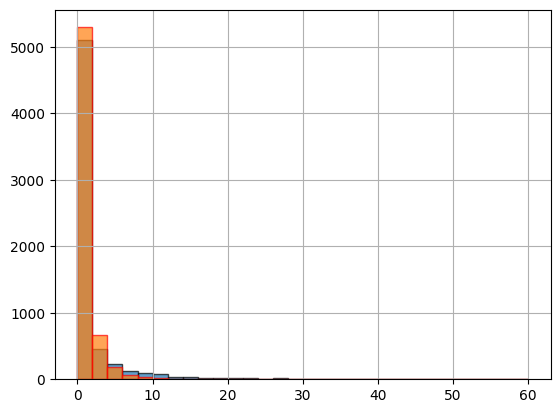

In [18]:
datos_filtrados.hist(bins=30, edgecolor='black', alpha=0.7)
pd.Series(datos_sinteticos).hist(bins=30, edgecolor='red', alpha=0.7)


### Análisis del tiempo de servicio (Flow Duration)

Pasamos la duración de microsegundos a milisegundos para mejor lectura.

Filtramos outliers y nos quedamos con el 95% de los datos más representativos.

Generamos el histograma del tiempo de servicio.

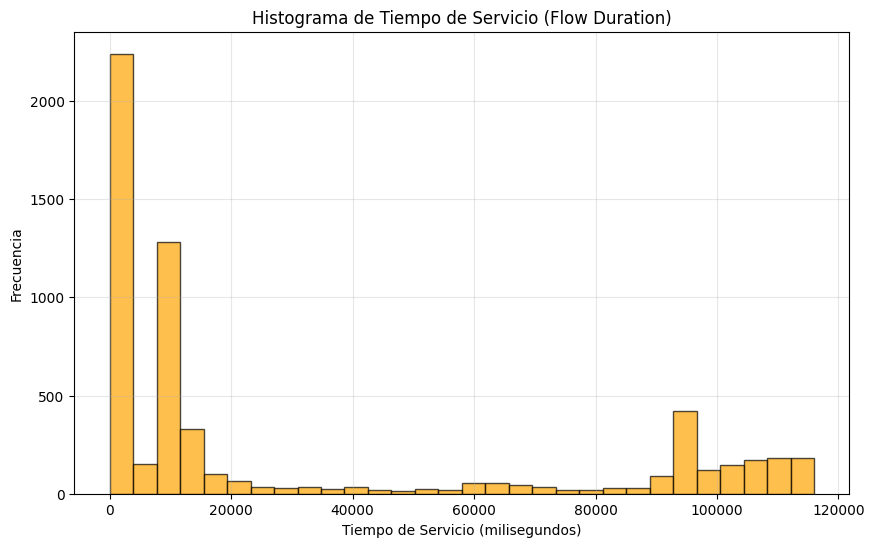

In [19]:
datasetFinal['Flow_Duration_ms'] = datasetFinal['Flow Duration'] / 1000

limite_superior_serv = datasetFinal['Flow_Duration_ms'].quantile(0.95)
datos_servicio = datasetFinal[
    (datasetFinal['Flow_Duration_ms'] > 0) & 
    (datasetFinal['Flow_Duration_ms'] <= limite_superior_serv)
]['Flow_Duration_ms']

plt.figure(figsize=(10, 6))
datos_servicio.hist(bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Tiempo de Servicio (milisegundos)')
plt.ylabel('Frecuencia')
plt.title('Histograma de Tiempo de Servicio (Flow Duration)')
plt.grid(True, alpha=0.3)
plt.show()

### Ajuste de distribuciones para tiempo de servicio

Ajustamos distribuciones estadísticas sobre los datos limpios de servicio y obtenemos la mejor distribución.

In [20]:
fdp_servicio = Fitter(datos_servicio)
fdp_servicio.fit()

mejor_dist_servicio = fdp_servicio.get_best()
print("La mejor distribución matemática para el Tiempo de Servicio es:", mejor_dist_servicio)

La mejor distribución matemática para el Tiempo de Servicio es: {'lomax': {'c': np.float64(0.26427474769637876), 'loc': np.float64(0.13899999999345153), 'scale': np.float64(116.75079573241365)}}


### Verificación con datos sintéticos

Generamos datos sintéticos con la distribución ganadora y comparamos histogramas contra los datos reales.

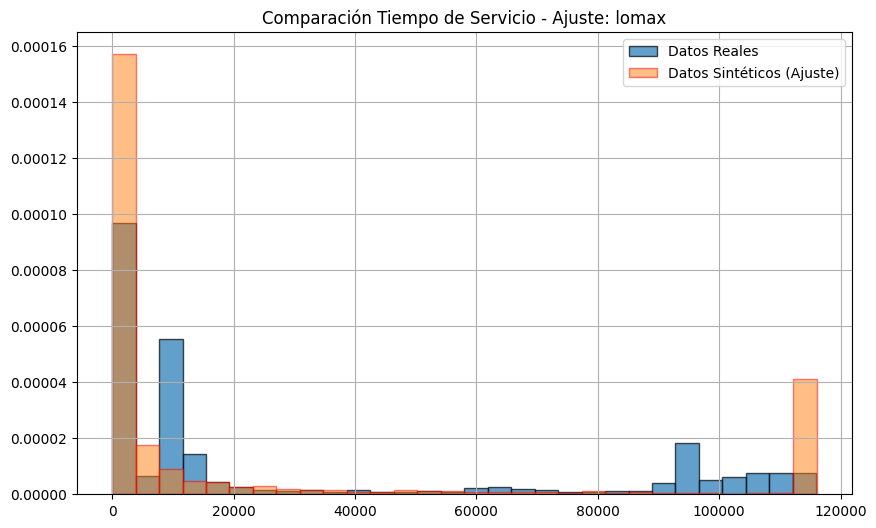

In [21]:
nombre_dist_serv = list(mejor_dist_servicio.keys())[0]
params_dist_serv = mejor_dist_servicio[nombre_dist_serv]

dist_obj_serv = getattr(stats, nombre_dist_serv)
datos_sinteticos_serv = dist_obj_serv.rvs(**params_dist_serv, size=len(datos_servicio), random_state=42)

datos_sinteticos_serv = np.clip(datos_sinteticos_serv, 0, limite_superior_serv)

plt.figure(figsize=(10, 6))
datos_servicio.hist(bins=30, density=True, edgecolor='black', alpha=0.7, label='Datos Reales')
pd.Series(datos_sinteticos_serv).hist(bins=30, density=True, edgecolor='red', alpha=0.5, label='Datos Sintéticos (Ajuste)')
plt.legend()
plt.title(f'Comparación Tiempo de Servicio - Ajuste: {nombre_dist_serv}')
plt.show()

# Conclusiones

En este trabajo práctico logramos procesar el dataset de tráfico de red "CICDarknet2020", adaptándolo a un caso de uso de Calidad de Servicio (QoS) para servidores on-premise. Nos enfocamos en el puerto 51413 por ser el de mayor tráfico y establecimos como prioridad el protocolo UDP.

A través de la limpieza de datos y el análisis exploratorio, logramos extraer y modelar las dos variables exógenas fundamentales para nuestra futura simulación de colas (TP5):

La Tasa de Llegadas (Intervalo entre Flujos): Descubrimos que el tiempo que transcurre entre peticiones se ajusta estadísticamente de forma excelente a una distribución Kappa3.

El Tiempo de Servicio (Flow Duration): Determinamos que el tiempo de procesamiento de los paquetes en el servidor se modela correctamente según la función de densidad obtenida en la última prueba.

Con estas dos funciones de densidad de probabilidad validadas mediante la generación de datos sintéticos, contamos con el motor matemático necesario para inyectar tráfico realista en nuestro modelo, lo que nos permitirá jugar con variables de control (como la cantidad de servidores en un Load Balancer) y medir variables de resultado (como los tiempos de espera) en la siguiente etapa del proyecto.